In [1]:
import platform
platform.platform()

'macOS-26.2-arm64-arm-64bit'

In [2]:
import sys
sys.version

'3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]'

In [3]:
import os
sys.path.append(os.path.abspath("../../.."))

In [4]:
import matplotlib
matplotlib.__version__

'3.10.8'

In [5]:
import matplotlib.pyplot as plt

In [6]:
import numpy as np
np.__version__

'1.23.5'

In [7]:
import pandas as pd
pd.__version__

'2.3.3'

In [8]:
from rdkit import Chem, rdBase
rdBase.rdkitVersion

'2023.09.1'

In [9]:
from SSMetrics import ecfp_metrics

In [10]:
df1 = pd.read_csv("../../../1_dataset/1_28descriptors/1_dataset/1_original/dataset.csv",
                  usecols=["InChI",
                          "K3FeCN6", "MesAcr+BF4-", "CuCl",
                          "Diacetyl", "T(p-OMe)PPCo", "Electrode"])
df1.shape

(4665, 7)

In [11]:
df1.columns

Index(['InChI', 'K3FeCN6', 'MesAcr+BF4-', 'CuCl', 'Diacetyl', 'T(p-OMe)PPCo',
       'Electrode'],
      dtype='object')

In [12]:
conditions = [["K3FeCN6",(255/255, 75/255, 0/255), "K$_3$[Fe(CN)$_6$]"],
              ["MesAcr+BF4-", (153/255, 0/255, 153/255), "MesAcr$^+$BF$_4^-$"],
              ["CuCl", (3/255, 175/255, 122/255), "CuCl"],
              ["Diacetyl", (246/255, 170/255, 0/255), "Diacetyl"],
              ["T(p-OMe)PPCo", (77/255, 196/255, 255/255), "T($p$-OMe)PPCo"],
              ["Electrode", (255/255, 128/255, 130/255), "Electrode"]]

In [13]:
li_numbers = []

li_2_2048_avg = []
li_2_2048_max = []
li_2_4096_avg = []
li_2_4096_max = []

li_3_2048_avg = []
li_3_2048_max = []
li_3_4096_avg = []
li_3_4096_max = []

li_4_2048_avg = []
li_4_2048_max = []
li_4_4096_avg = []
li_4_4096_max = []

In [14]:
def calc(li_avg, li_max, radius, nBits, number):
    for i in range(6):
        condition = conditions[i][0]
        
        print(f"\n{condition}, {radius}, {nBits}")
        df2 = df1[df1[condition] == 1]

        if number:
            li_numbers.append(len(df2))

        inchi_list = df2["InChI"].to_list()
        ss = ecfp_metrics.tanimoto(inchi_list, radius, nBits)
        li_avg.append(ss[0])
        li_max.append(ss[1])

In [15]:
calc(li_2_2048_avg, li_2_2048_max, 2, 2048, True)
calc(li_2_4096_avg, li_2_4096_max, 2, 4096, False)

calc(li_3_2048_avg, li_3_2048_max, 3, 2048, False)
calc(li_3_4096_avg, li_3_4096_max, 3, 4096, False)

calc(li_4_2048_avg, li_4_2048_max, 4, 2048, False)
calc(li_4_4096_avg, li_4_4096_max, 4, 4096, False)


K3FeCN6, 2, 2048
Average:	0.6621461349897533
Max:		0.8571428571428572
min:		0.0

MesAcr+BF4-, 2, 2048
Average:	0.6785795259572664
Max:		0.8709677419354839
min:		0.22916666666666663

CuCl, 2, 2048
Average:	0.5049934112309737
Max:		0.7045454545454546
min:		0.1724137931034483

Diacetyl, 2, 2048
Average:	0.6505728280740098
Max:		0.8333333333333334
min:		0.3529411764705882

T(p-OMe)PPCo, 2, 2048
Average:	0.706042067049705
Max:		0.868421052631579
min:		0.3846153846153846

Electrode, 2, 2048
Average:	0.6581655328558461
Max:		0.8409090909090909
min:		0.375

K3FeCN6, 2, 4096
Average:	0.6651755404542015
Max:		0.8604651162790697
min:		0.0

MesAcr+BF4-, 2, 4096
Average:	0.6811156412255822
Max:		0.896551724137931
min:		0.22448979591836737

CuCl, 2, 4096
Average:	0.5083040066662315
Max:		0.7073170731707317
min:		0.1724137931034483

Diacetyl, 2, 4096
Average:	0.6505728280740098
Max:		0.8333333333333334
min:		0.3529411764705882

T(p-OMe)PPCo, 2, 4096
Average:	0.7097760473782816
Max:		0.87179487179487

In [16]:
labels = []

for i in range(6):
    labels.append(f"{conditions[i][2]} ({li_numbers[i]})")
    
labels

['K$_3$[Fe(CN)$_6$] (23)',
 'MesAcr$^+$BF$_4^-$ (20)',
 'CuCl (19)',
 'Diacetyl (12)',
 'T($p$-OMe)PPCo (9)',
 'Electrode (9)']

In [17]:
df_result_avg = pd.DataFrame({"Condition": [e[0] for e in conditions],
                              "Number":li_numbers})

df_result_avg["radius=2,\nnBits=2048"] = li_2_2048_avg
df_result_avg["radius=2,\nnBits=4096"] = li_2_4096_avg
df_result_avg["radius=3,\nnBits=2048"] = li_3_2048_avg
df_result_avg["radius=3,\nnBits=4096"] = li_3_4096_avg
df_result_avg["radius=4,\nnBits=2048"] = li_4_2048_avg
df_result_avg["radius=4,\nnBits=4096"] = li_4_4096_avg

df_result_avg

,Condition,Number,"radius=2,\nnBits=2048","radius=2,\nnBits=4096","radius=3,\nnBits=2048","radius=3,\nnBits=4096","radius=4,\nnBits=2048","radius=4,\nnBits=4096"
0,K3FeCN6,23,0.662146,0.665176,0.733304,0.735311,0.750440,0.754015
1,MesAcr+BF4-,20,0.678580,0.681116,0.753390,0.756354,0.770117,0.772927
2,CuCl,19,0.504993,0.508304,0.624563,0.628743,0.666453,0.670946
3,Diacetyl,12,0.650573,0.650573,0.737375,0.738702,0.751141,0.752432
4,T(p-OMe)PPCo,9,0.706042,0.709776,0.772369,0.774618,0.779711,0.781709
5,Electrode,9,0.658166,0.661112,0.726205,0.729374,0.728917,0.734901


In [18]:
df_result_avg.to_csv("si_ecfp_tanimoto_avg.csv", index=False)

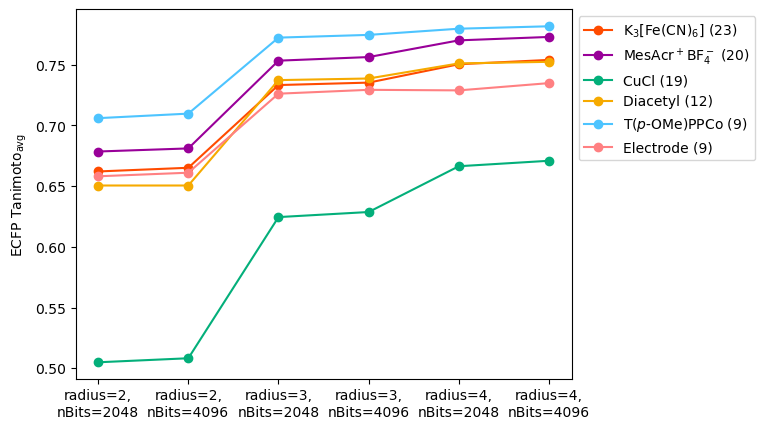

In [19]:
fig = plt.figure()
ax = fig.add_subplot()

for i in range(6):
    ax.plot(
        df_result_avg.iloc[i, 2:],
        marker="o",
        color=conditions[i][1],
        label=labels[i]
        )

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.set_ylabel("ECFP Tanimoto$_{\mathrm{avg}}$")

plt.savefig("si_ecfp_tanimoto_avg.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
df_result_max = pd.DataFrame({"Condition": [e[0] for e in conditions],
                              "Number":li_numbers})

df_result_max["radius=2,\nnBits=2048"] = li_2_2048_max
df_result_max["radius=2,\nnBits=4096"] = li_2_4096_max
df_result_max["radius=3,\nnBits=2048"] = li_3_2048_max
df_result_max["radius=3,\nnBits=4096"] = li_3_4096_max
df_result_max["radius=4,\nnBits=2048"] = li_4_2048_max
df_result_max["radius=4,\nnBits=4096"] = li_4_4096_max

df_result_max

,Condition,Number,"radius=2,\nnBits=2048","radius=2,\nnBits=4096","radius=3,\nnBits=2048","radius=3,\nnBits=4096","radius=4,\nnBits=2048","radius=4,\nnBits=4096"
0,K3FeCN6,23,0.857143,0.860465,0.896552,0.898305,0.906250,0.910448
1,MesAcr+BF4-,20,0.870968,0.896552,0.910112,0.923077,0.921569,0.931818
2,CuCl,19,0.704545,0.707317,0.796875,0.796875,0.833333,0.833333
3,Diacetyl,12,0.833333,0.833333,0.879310,0.879310,0.890625,0.890625
4,T(p-OMe)PPCo,9,0.868421,0.871795,0.907407,0.909091,0.915254,0.916667
5,Electrode,9,0.840909,0.844444,0.877193,0.879310,0.872727,0.883333


In [21]:
df_result_max.to_csv("si_ecfp_tanimoto_max.csv", index=False)

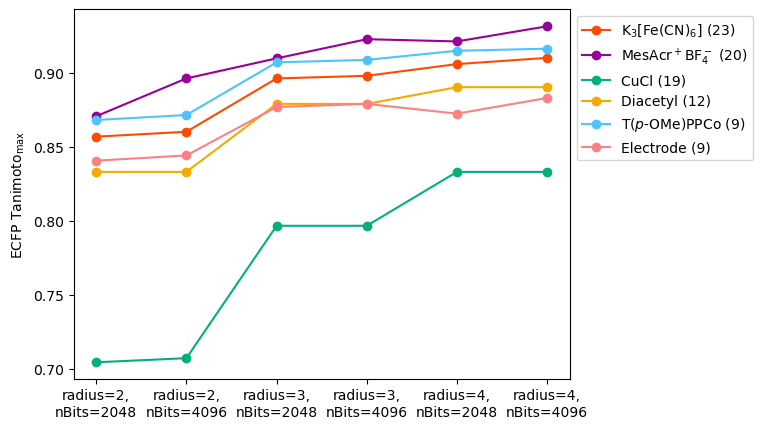

In [22]:
fig = plt.figure()
ax = fig.add_subplot()

for i in range(6):
    ax.plot(
        df_result_max.iloc[i, 2:],
        marker="o",
        color=conditions[i][1],
        label=labels[i]
        )

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.set_ylabel("ECFP Tanimoto$_{\mathrm{max}}$")

plt.savefig("si_ecfp_tanimoto_max.png", dpi=300, bbox_inches="tight")
plt.show()